In [4]:
import shutil
import os
os.environ["MPLBACKEND"] = "Agg"

os.chdir(r"C:/Users/hzghz/Desktop/深度学习/code/实验3/YOLOV5DETECT/yolov5-master")
print("当前目录：", os.getcwd())

当前目录： C:\Users\hzghz\Desktop\深度学习\code\实验3\YOLOV5DETECT\yolov5-master


In [31]:
!C:/Users/hzghz/Desktop/深度学习/code/实验3/.venv310/Scripts/python.exe train.py --img 200 --batch 16 --epochs 160 --patience 40 --weights yolov5m.pt --image-weights --device 0 --data ../NEU-DET/data.yaml --cos-lr --hyp hyp.custom.yaml

github: skipping check (not a git repository), for updates see https://github.com/ultralytics/yolov5


C:\Users\hzghz\Desktop\深度学习\code\实验3\YOLOV5DETECT\yolov5-master\utils\general.py:32: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
train: weights=yolov5m.pt, cfg=, data=../NEU-DET/data.yaml, hyp=hyp.custom.yaml, epochs=160, batch_size=16, imgsz=200, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=data\hyps, resume_evolve=None, bucket=, cache=None, image_weights=True, device=0, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=runs\train, name=exp, exist_ok=False, quad=False, cos_lr=True, label_smoothing=0.0, patience=40, freeze=[0], save_period=-1, seed=0, local_rank=-1, entity=None, upload_dataset=False, bbox_interval=-1, artifact_alias=latest, ndjson_consol

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("runs/train/exp7/results.csv")
df.columns = df.columns.str.strip()

print(df.head())

plt.figure(figsize=(12,6))
plt.plot(df["epoch"], df["metrics/mAP_0.5"], label="mAP@0.5")
plt.plot(df["epoch"], df["metrics/precision"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall"], label="Recall")

plt.legend()
plt.grid(True)
plt.show()

   epoch  train/box_loss  train/obj_loss  train/cls_loss  metrics/precision  \
0      0        0.095973        0.007708        0.014677            0.00578   
1      1        0.074368        0.009680        0.010837            0.50957   
2      2        0.067816        0.006920        0.008309            0.52189   
3      3        0.064907        0.006516        0.006481            0.40028   
4      4        0.062823        0.006556        0.005138            0.51256   

   metrics/recall  metrics/mAP_0.5  metrics/mAP_0.5:0.95  val/box_loss  \
0         0.75256          0.04559              0.014022      0.082432   
1         0.12831          0.14381              0.047084      0.061922   
2         0.33793          0.30280              0.127320      0.058239   
3         0.57955          0.45598              0.172530      0.053559   
4         0.57655          0.52500              0.206200      0.050437   

   val/obj_loss  val/cls_loss     x/lr0     x/lr1     x/lr2  
0      0.002289   

C:\Users\hzghz\AppData\Local\Temp\ipykernel_27892\2730828641.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [33]:
!C:/Users/hzghz/Desktop/深度学习/code/实验3/.venv310/Scripts/python.exe detect.py --weights runs/train/exp7/weights/best.pt --source "C:/Users/hzghz/Desktop/深度学习/code/实验3/YOLOV5DETECT/NEU-DET/valid/images" --img 200 --conf 0.25 --device 0 --project runs/detect --name test_result

C:\Users\hzghz\Desktop\深度学习\code\实验3\YOLOV5DETECT\yolov5-master\utils\general.py:32: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
detect: weights=['runs/train/exp7/weights/best.pt'], source=C:/Users/hzghz/Desktop//code/3/YOLOV5DETECT/NEU-DET/valid/images, data=data\coco128.yaml, imgsz=[200, 200], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=0, view_img=False, save_txt=False, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=test_result, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5  2026-4-27 Python-3.10.0 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 81

In [34]:
!C:/Users/hzghz/Desktop/深度学习/code/实验3/.venv310/Scripts/python.exe val.py --weights runs/train/exp7/weights/best.pt --data ../NEU-DET/data.yaml --img 200 --device 0 --task val

C:\Users\hzghz\Desktop\深度学习\code\实验3\YOLOV5DETECT\yolov5-master\utils\general.py:32: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
val: data=../NEU-DET/data.yaml, weights=['runs/train/exp7/weights/best.pt'], batch_size=32, imgsz=200, conf_thres=0.001, iou_thres=0.6, max_det=300, task=val, device=0, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs\val, name=exp, exist_ok=False, half=False, dnn=False
YOLOv5  2026-4-27 Python-3.10.0 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)

Fusing layers... 
Model summary: 212 layers, 20873139 parameters, 0 gradients, 47.9 GFLOPs
WARNING  --img-size 200 must be multiple of max stride 32, updating to 224

val: Sca

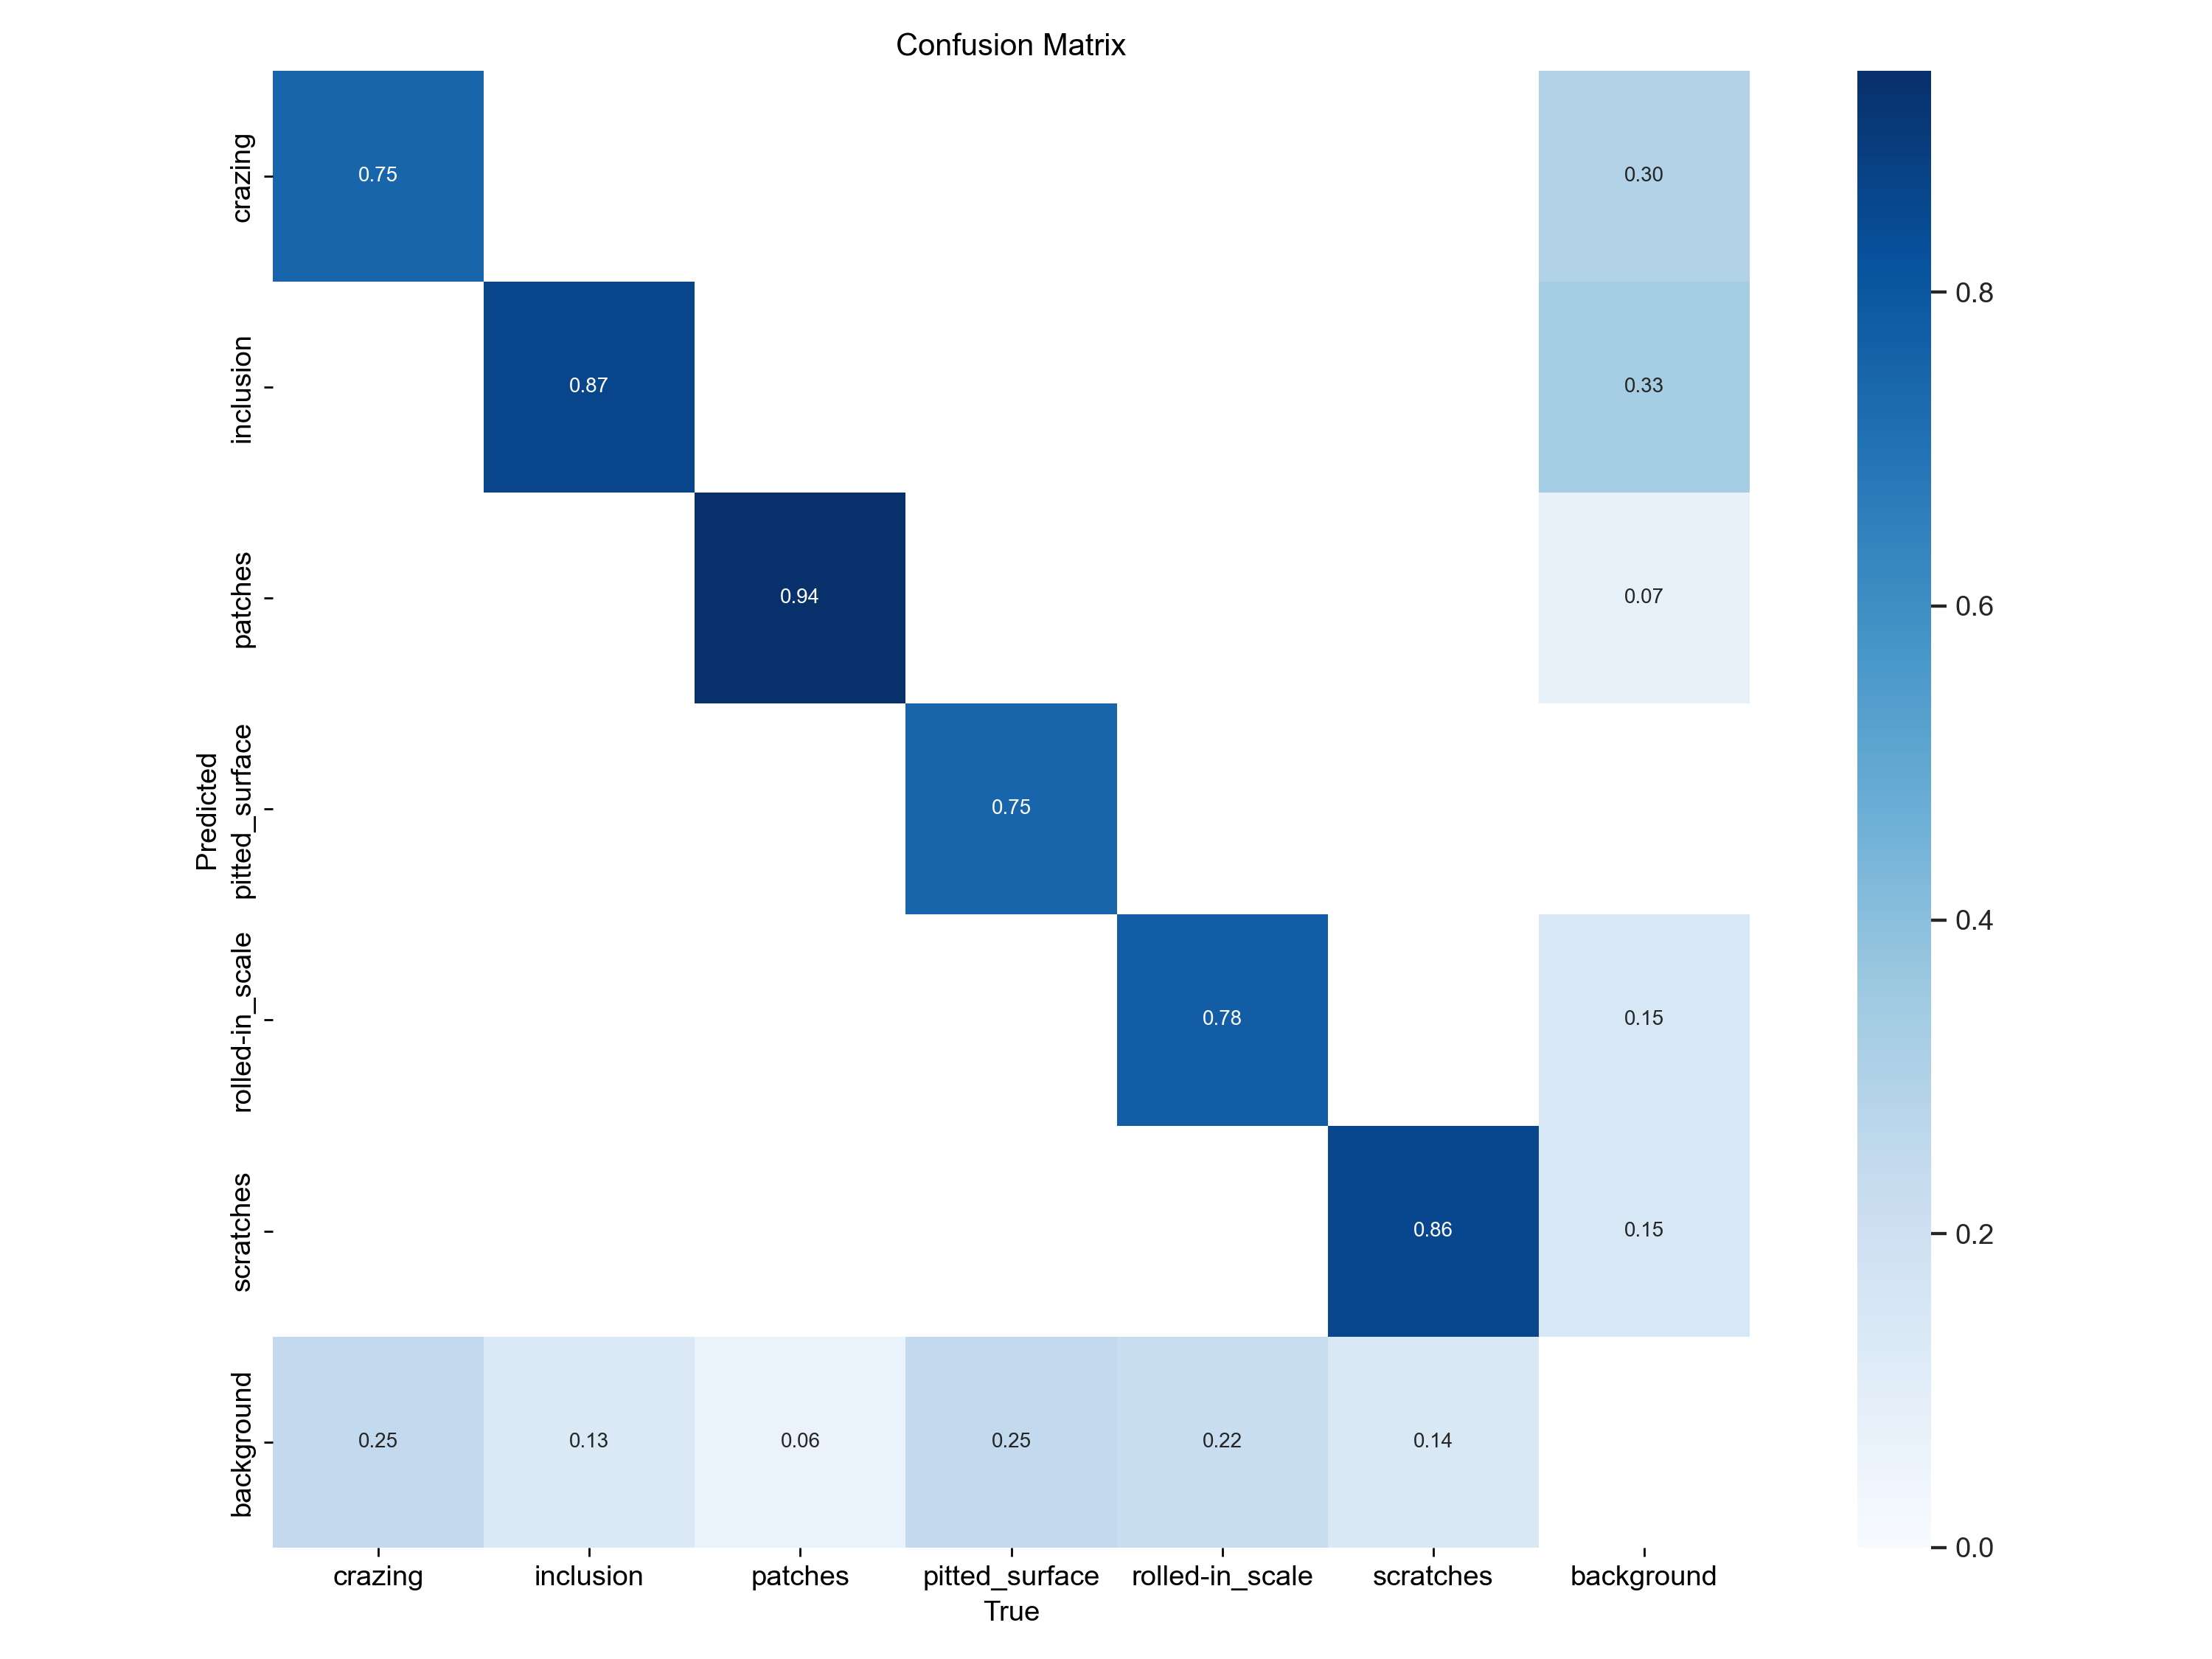

In [36]:
img_path = 'runs/val/exp7/confusion_matrix.png'   
display(Image(filename=img_path))